Dataset Shape: (701548, 6)
      lat     lon  pressure  temperature  humidity
0  42.738  23.272  95270.27        23.46     62.48
1  42.663  23.273  94355.83        23.06     59.46
2  42.700  23.360  95155.81        26.53     44.38
3  42.624  23.406  94679.57        28.34     38.28
4  42.669  23.318  94327.88        26.31     46.37
                 lat            lon       pressure    temperature  \
count  697513.000000  697513.000000  697513.000000  697513.000000   
mean       42.679680      23.333633   94878.877607      25.675188   
std         0.025633       0.039450     761.642105       6.457013   
min        42.622000      23.240000       0.000000    -145.120000   
25%        42.664000      23.310000   94524.780000      20.700000   
50%        42.683000      23.332000   95001.390000      24.830000   
75%        42.694000      23.360000   95398.800000      29.910000   
max        42.738000      23.419000  164926.750000      61.170000   

            humidity  
count  697513.000000  

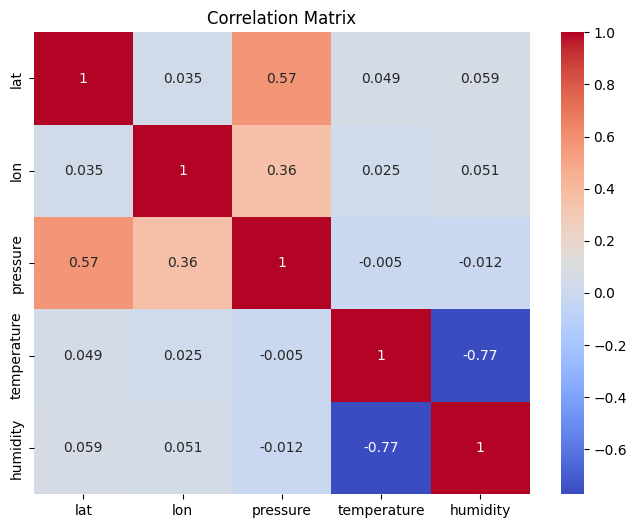


Model Performance Comparison
                   Model  R2 Score      RMSE       MAE
3                XGBoost  0.900858  2.033508  1.466454
2          Random Forest  0.886584  2.174972  1.590646
1  Polynomial Regression  0.817525  2.758793  2.057153
0      Linear Regression  0.652816  3.805371  2.685517

Best Model : XGBoost
Best R2 Score : 0.9009


In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# Load Dataset


df = pd.read_csv("humidity.csv")

print("Dataset Shape:", df.shape)


# Data Cleaning


df.drop_duplicates(inplace=True)
df.dropna(inplace=True)

if "sensor_id" in df.columns:
    df.drop("sensor_id", axis=1, inplace=True)


# Exploratory Data Analysis


print(df.head())

print(df.describe())

print(df.isnull().sum())

# Correlation Matrix

plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()


# Feature Engineering


df["humidity_pressure"] = (
    df["humidity"] * df["pressure"]
)

df["humidity_sq"] = (
    df["humidity"] ** 2
)

df["pressure_sq"] = (
    df["pressure"] ** 2
)


# Features and Target


X = df.drop("temperature", axis=1)

y = df["temperature"]


# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# Scaling


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Model Evaluation Function


results = []

def evaluate_model(
    model_name,
    model,
    X_test_data
):

    y_pred = model.predict(X_test_data)

    r2 = r2_score(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    results.append([
        model_name,
        r2,
        rmse,
        mae
    ])


# Linear Regression


lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)

evaluate_model(
    "Linear Regression",
    lr,
    X_test_scaled
)


# Polynomial Regression


poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("lr", LinearRegression())
])

poly.fit(
    X_train_scaled,
    y_train
)

evaluate_model(
    "Polynomial Regression",
    poly,
    X_test_scaled
)


# Random Forest


rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

evaluate_model(
    "Random Forest",
    rf,
    X_test
)


# XGBoost


xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train
)

evaluate_model(
    "XGBoost",
    xgb,
    X_test
)


# Results


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2 Score",
        "RMSE",
        "MAE"
    ]
)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\nModel Performance Comparison")
print(results_df)


# Best Model


best_model = results_df.iloc[0]

print("\nBest Model :", best_model["Model"])
print("Best R2 Score :", round(best_model["R2 Score"],4))